# EDA Analítico — Core features

> **Múltiples ligas**&nbsp;&nbsp;◦&nbsp;&nbsp;**Temporadas:** 2014-15 → 2023-24&nbsp;&nbsp;◦&nbsp;&nbsp;**Fuentes:** core_features.parquet

## Objetivos

- Analizar el home advantage y la calibración del xG sobre el dataset enriquecido.
- Verificar distribuciones, outliers y asimetrías de las 10 features construidas en Fase 6.
- Medir poder discriminativo de cada feature respecto al target `FTR` (η²).
- Detectar colinealidad entre features.
- Producir tabla resumen con decisiones para Fase 7 (Modelado).

## Estructura del Notebook

| # | Sección | Dataset | Objetivo |
|---|---------|---------|----------|
| 0 | Entorno y configuración | ambos | Librerías, rutas, carga de datasets |
| 1 | Distribución target | core_features | Barplot FTR con % |
| 2 | Estadísticos descriptivos | core_features | describe + skewness + kurtosis |
| 3 | Histogramas | core_features | Distribución individual de cada feature |
| 4 | Correlación | core_features | Heatmap anotado entre features |
| 5 | Violin plots | core_features | Distribución por clase FTR |
| 6 | Eta² | core_features | Correlation ratio feature vs FTR |
| 7 | Conclusiones | ambos | Tabla resumen y decisiones para Fase 7 |

---
##

## 0) Entorno y configuración

### 0.1 Imports y rutas

Dependencias, rutas del proyecto y constantes de referencia.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys

import matplotlib.pyplot as plt
import seaborn as sns

# Rutas del proyecto
PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_ROOT  = PROJECT_ROOT / "data" / "processed"
CORE_FEATURES_PATH = PROCESSED_ROOT / "core_features.parquet"

from src.features.build_features import FEATURES, FEATURES_ROLLING

### 0.2 Carga y verificación

Lectura de `core_features.parquet` y auditoría básica.

In [3]:
df      = pd.read_parquet(CORE_FEATURES_PATH)
n_nulos = df[FEATURES].isna().sum().sum()

print(f"{'─'*50}")
print(f"  Shape         : {df.shape[0]:,} partidos × {df.shape[1]} columnas")
print(f"  Rango         : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Temporadas    : {sorted(df['Season'].unique())[0]} → {sorted(df['Season'].unique())[-1]}")
print(f"  Ligas         : {', '.join(sorted(df['League'].unique()))}")
print(f"  Nulos         : {n_nulos}")
print(f"{'─'*50}")

assert n_nulos == 0, "⚠ Hay nulos en las features"

──────────────────────────────────────────────────
  Shape         : 9,792 partidos × 17 columnas
  Rango         : 2014-11-07 → 2024-05-26
  Temporadas    : 2015 → 2024
  Ligas         : bundesliga, laliga, premier
  Nulos         : 0
──────────────────────────────────────────────────


---
##

## 1) Distribución del target `FTR`

Distribución de categorías del target (`H` / `D` / `A`) para evaluar el desbalance del conjunto de datos.

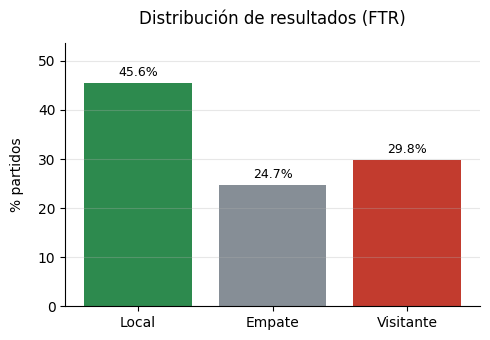

In [4]:
conteo_ftr = df["FTR"].value_counts().reindex(["H", "D", "A"])
pct_ftr = conteo_ftr / len(df) * 100

fig, ax = plt.subplots(figsize=(5, 3.5))

barras = ax.bar(["Local", "Empate", "Visitante"], pct_ftr,
                color=["#2d8a4e", "#868e96", "#c23b2e"])

ax.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_title("Distribución de resultados (FTR)", pad=14, fontsize=12)
ax.set_ylabel("% partidos", labelpad=10)
ax.set_ylim(0, pct_ftr.max() + 8)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
##

## 2) Estadísticos descriptivos

Estadísticos descriptivos ampliados con medidas de forma (asimetría y curtosis) para identificar distribuciones sesgadas y la presencia de valores extremos.

In [5]:
desc = (
    df[FEATURES]
    .describe()
    .T
    .assign(
        skew=df[FEATURES].skew(),
        kurtosis=df[FEATURES].kurtosis()
    )
)

cols = ["mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]
print(desc[cols].round(3).to_string())

alertas = {
    "asimetria": desc.index[desc["skew"].abs() > 1].tolist(),
    "curtosis": desc.index[desc["kurtosis"] > 3].tolist()
}

print("\nAlertas de distribución:\n------------------------")
print(f"- |skewness| > 1: {', '.join(alertas['asimetria']) or 'ninguna'}")
print(f"- kurtosis > 3: {', '.join(alertas['curtosis']) or 'ninguna'}")

                                mean      std      min     25%    50%     75%      max   skew  kurtosis
elo_diff_pre                  -1.285  134.016 -458.948 -82.485 -1.849  80.210  462.524  0.005     0.129
points_diff_global            -0.188   15.000  -66.000  -8.000  0.000   8.000   74.000 -0.016     1.462
points_diff_venue              3.926    8.508  -30.000  -1.000  3.000   9.000   41.000  0.453     0.953
goal_diff_last5_global        -0.073    1.437   -5.800  -1.000  0.000   0.800    5.600  0.015     0.246
xg_diff_last5_global          -0.076    1.114   -4.259  -0.807 -0.092   0.670    4.271  0.005     0.160
xg_conceded_diff_last5_global  0.039    0.621   -2.083  -0.375  0.040   0.451    2.420 -0.000     0.008
sot_diff_last5_global         -0.208    3.019  -11.400  -2.200 -0.200   1.800    9.800  0.007     0.071
goal_diff_last5_venue          0.699    1.438   -4.600  -0.200  0.600   1.600    6.800  0.062     0.242
rest_days_diff                -0.017    2.719 -102.000  -1.000  

### 2.1 Ánalisis de las alertas

In [6]:
umbral = 20

outliers = (
    df.loc[df["rest_days_diff"].abs() > umbral,
           ["Date", "Season", "League", "HomeTeam", "AwayTeam", "rest_days_diff"]]
      .sort_values("rest_days_diff", ascending=False)
)

covid_per_league = (
    df.loc[(df["Season"] == "2020") & (df["Date"] > "2020-06-01")]
      .groupby("League")
      .size()
)

print(f"\nOutliers en rest_days_diff (> {umbral} días)")
display(outliers.head(10))

print("\nResumen partidos post-COVID:")
print("----------------------------")
for liga, n in covid_per_league.items():
    print(f"- {liga.capitalize():<10}: {n:>3}")

print(f"\nTotal partidos afectados: {covid_per_league.sum()}")


Outliers en rest_days_diff (> 20 días)


,Date,Season,League,HomeTeam,AwayTeam,rest_days_diff
5536,2020-06-20,2020,premier,Brighton,Arsenal,102.0
5553,2020-06-21,2020,premier,Newcastle,Sheffield United,102.0
5554,2020-06-21,2020,premier,Aston Villa,Chelsea,-101.0
5560,2020-06-22,2020,premier,Man City,Burnley,-102.0



Resumen partidos post-COVID:
----------------------------
- Bundesliga:  46
- Laliga    : 110
- Premier   :  92

Total partidos afectados: 248


---
##

## 3) Distribución de features

Distribución de cada feature mediante histogramas, incluyendo la media, para evaluar la simetría y detectar posibles valores atípicos.

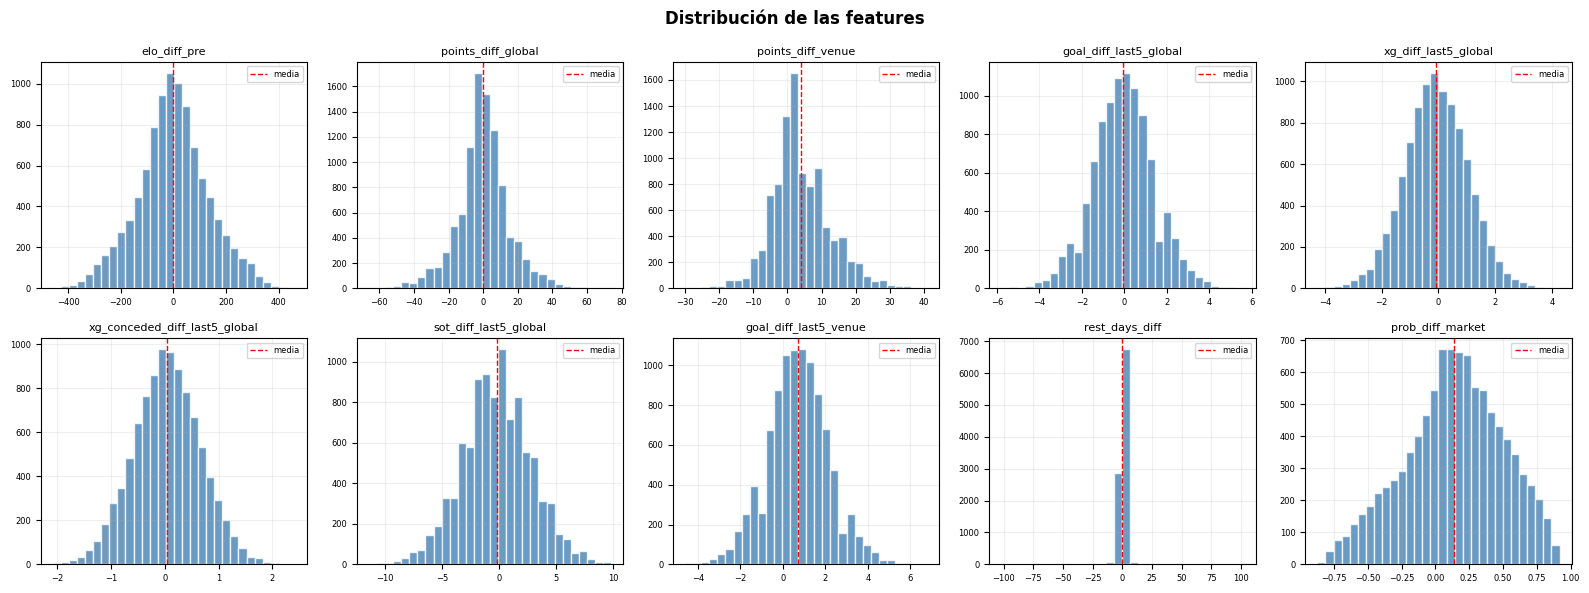

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))

for i, feat in enumerate(FEATURES):
    ax = axes.flat[i]
    x = df[feat]
    ax.hist(x, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(x.mean(), color="red", linestyle="--", linewidth=1, label="media")
    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=6)

fig.suptitle("Distribución de las features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
##

## 4) Correlación entre features

Heatmap de correlación de Pearson (triangular inferior) para identificar relaciones lineales y posibles problemas de colinealidad entre features.

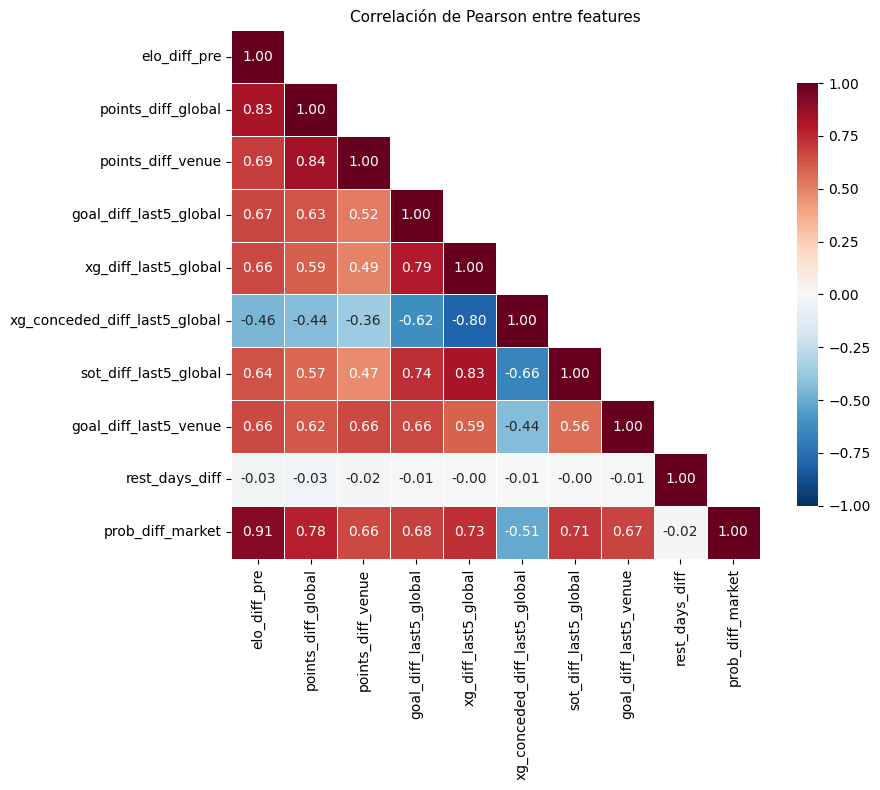

In [13]:
corr = df[FEATURES].corr()

mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlación de Pearson entre features", fontsize=11)
plt.tight_layout()
plt.show()

---
##

## 5) Distribución de features por resultado 

Distribución de cada feature según el resultado del partido (`H`, `D`, `A`), representada mediante violin plots.

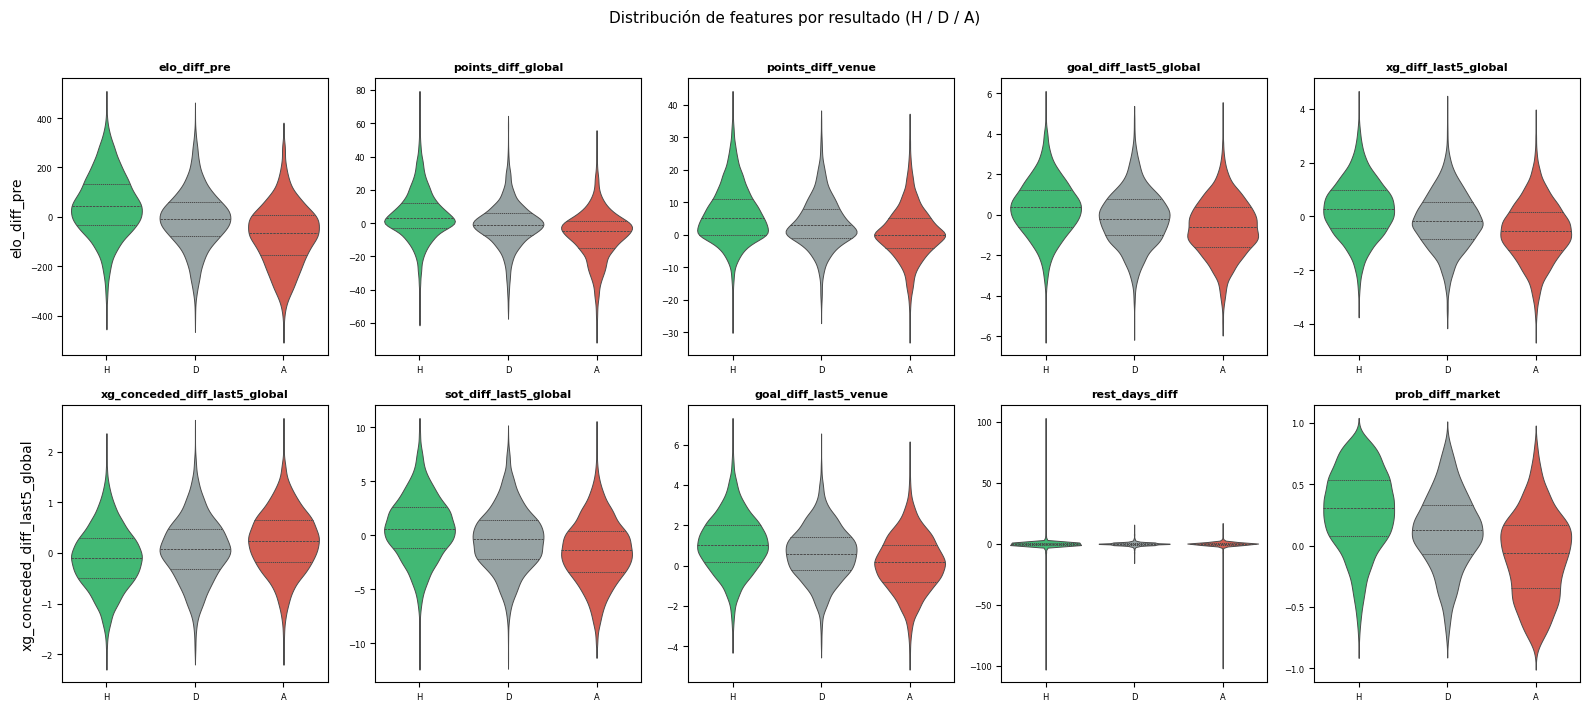

In [9]:
colores_ftr = {"H": "#2ecc71", "D": "#95a5a6", "A": "#e74c3c"}
orden_ftr   = ["H", "D", "A"]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for i, feat in enumerate(FEATURES):
    ax = axes.flat[i]
    sns.violinplot(data=df, x="FTR", y=feat, order=orden_ftr,
               hue="FTR", hue_order=orden_ftr, palette=colores_ftr,
               legend=False, inner="quartile", ax=ax, linewidth=0.7)
    ax.set_title(feat, fontsize=8, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("" if i % 5 != 0 else feat)
    ax.tick_params(labelsize=6)

fig.suptitle("Distribución de features por resultado (H / D / A)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
##

## 6) Poder discriminativo de las features (η²)

El correlation ratio (η²) mide cuánto cambia cada feature según el resultado (`FTR`). 

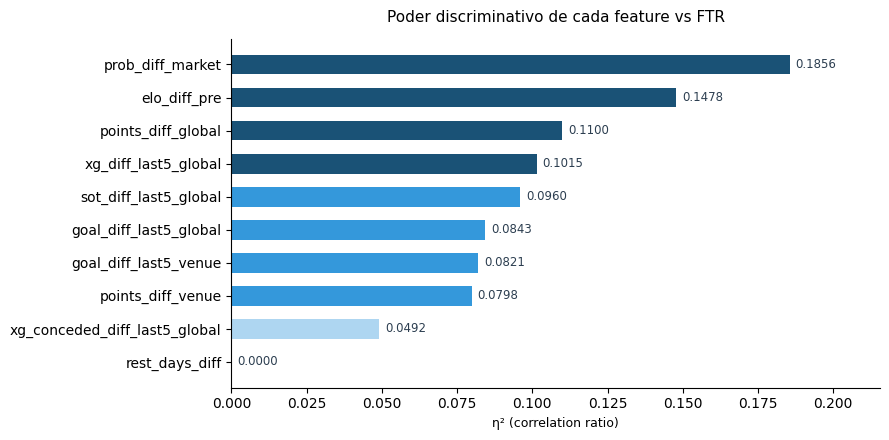

In [14]:
def _eta_squared(feature: pd.Series, grupo: pd.Series) -> float:
    media_global = feature.mean()
    grupos       = feature.groupby(grupo)
    ss_between   = sum(len(g) * (g.mean() - media_global) ** 2 for _, g in grupos)
    ss_total     = ((feature - media_global) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else 0.0


eta2        = {feat: _eta_squared(df[feat], df["FTR"]) for feat in FEATURES}
eta2_series = pd.Series(eta2).sort_values(ascending=False)

colores = ["#1a5276" if v > 0.10 else "#3498db" if v > 0.05 else "#aed6f1"
           for v in eta2_series]

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.barh(eta2_series.index, eta2_series.values,
                 color=colores, edgecolor="none", height=0.6)

for barra, val in zip(barras, eta2_series.values):
    ax.text(barra.get_width() + 0.002, barra.get_y() + barra.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8.5, color="#2c3e50")

ax.set_xlabel("η² (correlation ratio)", fontsize=9)
ax.set_title("Poder discriminativo de cada feature vs FTR", fontsize=11, pad=12)
ax.set_xlim(0, eta2_series.max() + 0.03)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
##

## 7) Conclusiones

Se ha analizado el `core_features` desde cinco dimensiones: distribución del target, 
estadísticos descriptivos, distribuciones individuales y por clase (`H`/`D`/`A`), correlación entre features y poder discriminativo respecto a `FTR`. 

### Hallazgos principales

#### Target
- **H (Local): 45.6% · D (Empate): 24.7% · A (Visitante): 29.8%**
- Ligero desbalance hacia victorias locales.
- Sin features: baseline = **45.6% accuracy** (predecir siempre H).
- Cualquier modelo debe superar este umbral.

#### Distribuciones
- Sin asimetrías relevantes (**|skewness| < 1** en todas las variables).
- Única anomalía: `rest_days_diff` con **kurtosis = 802**.
- Outliers de hasta **±102 días**, explicados por el parón COVID-19 (2020).
- Impacto acotado: **248 partidos afectados**, solo **4 casos extremos**.
- No requiere tratamiento adicional de momento.

#### Colinealidad destacada (|r| > 0.7)

| Par | r | Explicación |
|-----|---|-------------|
| `prob_diff_market` ↔ `elo_diff_pre` | 0.91 |  Ambas miden la diferencia de nivel entre equipos |
| `points_diff_global` ↔ `points_diff_venue` | 0.84 | Clasificación general y por localía muy similares |
| `xg_diff_last5_global` ↔ `sot_diff_last5_global` | 0.83 | Más tiros implica más xG por construcción |
| `elo_diff_pre` ↔ `points_diff_global` | 0.83 | ELO y clasificación reflejan nivel similar |

*Se muestran solo las correlaciones más altas.*

La colinealidad es manejable dado que cada par comparte varianza pero no es idéntico, y los modelos están diseñados por bloques conceptuales con features que no siempre conviven. `rest_days_diff` es la única feature independiente al resto (r≈0 con todas).

#### Poder discriminativo (η²)

| Nivel | Features | η² |
|-------|----------|----|
| Alto | `prob_diff_market`, `elo_diff_pre` | 0.19 / 0.15 |
| Medio-alto | `points_diff_global`, `xg_diff_last5_global`, `sot_diff_last5_global` | 0.10 – 0.11 |
| Medio | `goal_diff_last5_global`, `goal_diff_last5_venue`, `points_diff_venue` | 0.08 – 0.09 |
| Bajo | `xg_conceded_diff_last5_global`, `rest_days_diff` | 0.05 / ≈0 |

Las features de mercado y ELO concentran la mayor parte de la señal; el bloque rolling 
aporta información complementaria sobre forma reciente. `xg_conceded_diff_last5_global` 
y `rest_days_diff` se evaluarán en contexto con el resto de features.